In [107]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [108]:
import pandas as pd

In [109]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [110]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [111]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [112]:
df.shape

(2640, 12)

In [113]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [114]:
df.dtypes

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

In [115]:
df['Region'].value_counts()

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

In [116]:
df['Model'].value_counts()

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

In [117]:
df['Source_Type'].value_counts()

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64

In [118]:
df = df.drop_duplicates()

In [119]:
df.shape

(2640, 12)

In [120]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

In [121]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2021-10-01
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2019-07-01
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,2019-09-01
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2020-05-01


In [122]:
df = df.drop(columns=['Year', 'Month'])

In [123]:
df

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01
...,...,...,...,...,...,...,...,...,...,...,...
2635,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2021-10-01
2636,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2019-07-01
2637,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,2019-09-01
2638,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2020-05-01


In [124]:

region_map = {'Asia': 1, 'Europe': 2, 'Middle East': 3, 'North America': 4}
model_map = {'Cybertruck': 1, 'Model 3': 2, 'Model S': 3, 'Model X': 4, 'Model Y': 5}
source_map = {'Estimated (Region)': 1, 'Interpolated (Month)': 2, 'Official (Quarter)': 3}

#directly apply mapping
df['Region'] = df['Region'].map(region_map)
df['Model'] = df['Model'].map(model_map)
df['Source_Type'] = df['Source_Type'].map(source_map)


df.head()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2,3,17646,17922,92874.27,120,704,1863.42,2,12207,2023-05-01
1,1,4,3797,4164,62205.65,75,438,249.46,3,7640,2015-02-01
2,4,4,8411,9189,117887.32,82,480,605.59,2,14071,2019-01-01
3,4,2,6555,7311,89294.91,120,712,700.07,3,9333,2021-02-01
4,3,5,12374,13537,114846.78,120,661,1226.88,1,8722,2016-12-01


In [125]:

df_encoded = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)
df_encoded.head()

,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Region_2,Region_3,Region_4,Model_2,Model_3,Model_4,Model_5,Source_Type_2,Source_Type_3
0,17646,17922,92874.27,120,704,1863.42,12207,2023-05-01,True,False,False,False,True,False,False,True,False
1,3797,4164,62205.65,75,438,249.46,7640,2015-02-01,False,False,False,False,False,True,False,False,True
2,8411,9189,117887.32,82,480,605.59,14071,2019-01-01,False,False,True,False,False,True,False,True,False
3,6555,7311,89294.91,120,712,700.07,9333,2021-02-01,False,False,True,True,False,False,False,False,True
4,12374,13537,114846.78,120,661,1226.88,8722,2016-12-01,False,True,False,False,False,False,True,False,False


In [126]:
df.dtypes

Region                           int64
Model                            int64
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                      int64
Charging_Stations                int64
Date                    datetime64[ns]
dtype: object

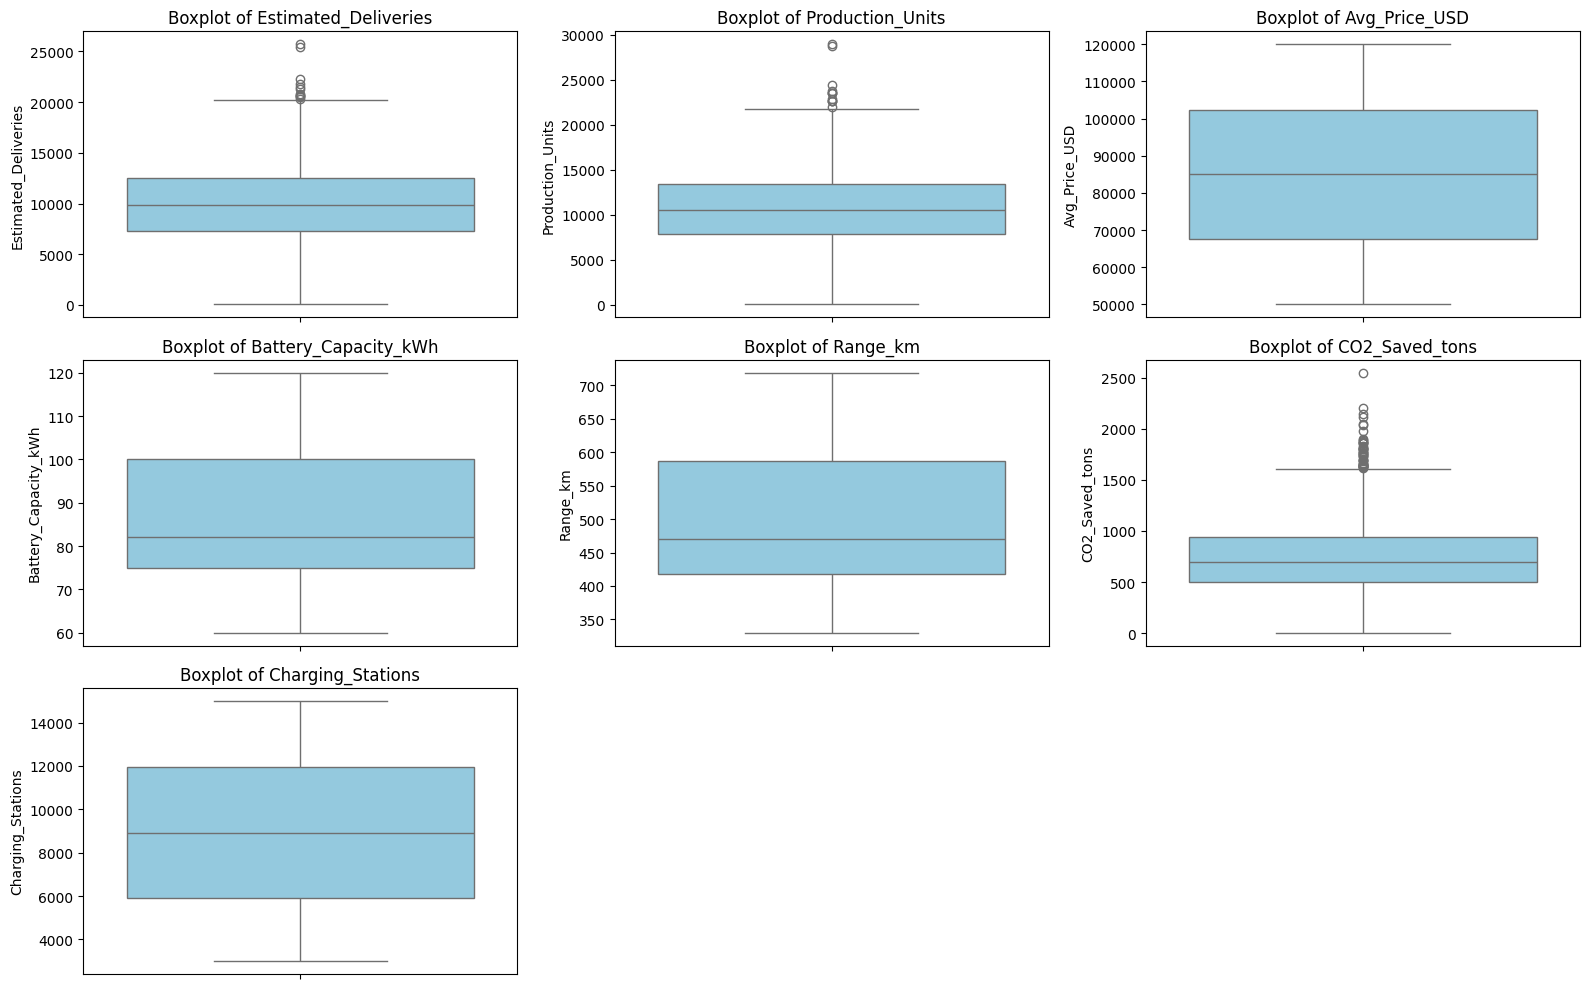

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [128]:
df2 = df.copy()


for col in df2.select_dtypes(include=np.number).columns:
    df2[col].fillna(df2[col].median(), inplace=True)


/tmp/ipykernel_58/863958153.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].fillna(df2[col].median(), inplace=True)


In [129]:
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    Q1, Q3 = df2[col].quantile(0.25), df2[col].quantile(0.75)
    IQR = Q3 - Q1
    df2[col] = df2[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("Null values after fill :", df2.isnull().sum().sum())
print("Shape                  :", df2.shape)

Null values after fill : 0
Shape                  : (2640, 11)


Text(0.5, 1.0, 'Price Distribution')

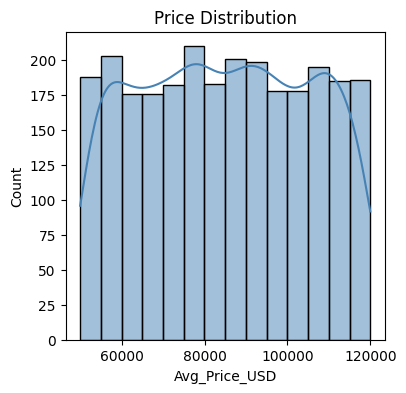

In [130]:
# Distribution of Avg_Price_USD
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(df2['Avg_Price_USD'], kde=True, color='steelblue')
plt.title('Price Distribution')

In [131]:
# Avg price by Model

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '4'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '5')])

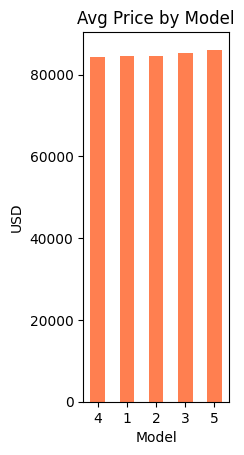

In [132]:

plt.subplot(1, 3, 2)
df2.groupby('Model')['Avg_Price_USD'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Avg Price by Model')
plt.ylabel('USD')
plt.xticks(rotation=0)

In [133]:
# Deliveries vs Price scatter

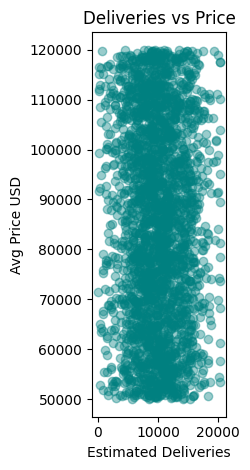

In [134]:

plt.subplot(1, 3, 3)
plt.scatter(df2['Estimated_Deliveries'], df2['Avg_Price_USD'], alpha=0.4, color='teal')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Avg Price USD')
plt.title('Deliveries vs Price')

plt.tight_layout()
plt.show()


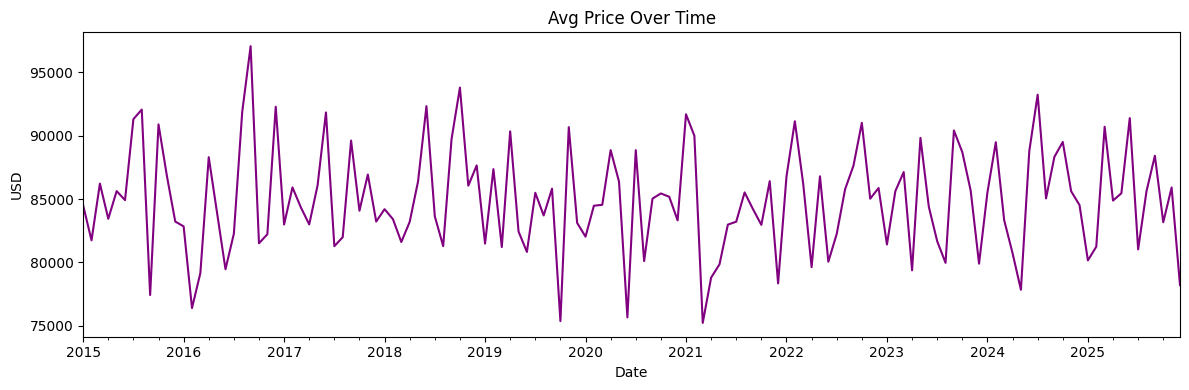

Avg Price USD stats:
 count      2640.00
mean      84907.34
std       20123.26
min       50003.70
25%       67726.36
50%       85058.51
75%      102373.04
max      119965.36
Name: Avg_Price_USD, dtype: float64


In [135]:
plt.figure(figsize=(12, 4))
df2.groupby('Date')['Avg_Price_USD'].mean().plot(color='purple')
plt.title('Avg Price Over Time')
plt.xlabel('Date')
plt.ylabel('USD')
plt.tight_layout()
plt.show()

print("Avg Price USD stats:\n", df2['Avg_Price_USD'].describe().round(2))

In [136]:

print("\n>>> FEATURE ENGINEERING")
df2 = df_encoded.copy()  

df2['Month_num'] = df2['Date'].dt.month
df2['Year_num'] = df2['Date'].dt.year
df2['Quarter'] = df2['Date'].dt.quarter
df2['Delivery_per_unit'] = df2['Estimated_Deliveries'] / (df2['Production_Units'] + 1)
df2['High_season'] = df2['Quarter'].isin([3, 4]).astype(int)


print("Final shape:", df2.shape)


>>> FEATURE ENGINEERING
Final shape: (2640, 22)


In [137]:
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [138]:
print("\n>>> REGRESSION MODELING")


base_features = [
    'Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh', 
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Month_num', 
    'Year_num', 'Quarter', 'Delivery_per_unit', 'High_season'
]

encoded_features = [col for col in df2.columns if '_' in col and col not in ['Avg_Price_USD', 'Month_num', 'Year_num', 'Delivery_per_unit', 'High_season']]

features = base_features + encoded_features

X = df2[features]
y = df2['Avg_Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    results[name] = {
        'MAE': round(mean_absolute_error(y_test, p), 2),
        'RMSE': round(mean_squared_error(y_test, p) ** 0.5, 2),
        'R²': round(r2_score(y_test, p), 4),
    }
print(pd.DataFrame(results).T.to_string())
print(df2.corr()['Avg_Price_USD'].sort_values(ascending=False))



>>> REGRESSION MODELING
                        MAE      RMSE      R²
Linear Regression  16827.40  19532.94 -0.0117
Random Forest      17254.45  20173.43 -0.0792
Gradient Boosting  17128.59  19970.18 -0.0575
Avg_Price_USD           1.000000
Region_2                0.034447
High_season             0.029982
Model_5                 0.029173
Month_num               0.024857
Quarter                 0.024366
Source_Type_3           0.013603
Model_3                 0.006910
Delivery_per_unit       0.001143
Date                   -0.002705
Source_Type_2          -0.003253
Year_num               -0.004991
Model_2                -0.009427
Region_3               -0.010656
Model_4                -0.016505
Charging_Stations      -0.017790
Range_km               -0.017854
Battery_Capacity_kWh   -0.018203
Estimated_Deliveries   -0.027546
CO2_Saved_tons         -0.028523
Production_Units       -0.029263
Region_4               -0.031091
Name: Avg_Price_USD, dtype: float64


In [139]:
print("\n>>> REGRESSION MODELING (Predicting Deliveries)")


base_features = [
    'Production_Units', 'Battery_Capacity_kWh', 'Range_km', 
    'CO2_Saved_tons', 'Charging_Stations', 'Month_num', 
    'Year_num', 'Quarter', 'High_season', 'Avg_Price_USD'
]
encoded_features = [col for col in df2.columns if '_' in col and col not in ['Estimated_Deliveries', 'Month_num', 'Year_num', 'Delivery_per_unit', 'High_season']]
features = base_features + encoded_features

X = df2[features]
y = df2['Estimated_Deliveries'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    results[name] = {
        'MAE': round(mean_absolute_error(y_test, p), 2),
        'RMSE': round(mean_squared_error(y_test, p) ** 0.5, 2),
        'R²': round(r2_score(y_test, p), 4),
    }
print(pd.DataFrame(results).T.to_string())


>>> REGRESSION MODELING (Predicting Deliveries)
                      MAE    RMSE      R²
Linear Regression  309.75  384.11  0.9901
Random Forest      321.85  405.33  0.9890
Gradient Boosting  324.22  400.66  0.9892


In [140]:
print("\n>>> HYPERPARAMETER TUNING (Random Forest)")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_
best_preds = best.predict(X_test)

print("Best params :", grid.best_params_)
print("Tuned R²    :", round(r2_score(y_test, best_preds), 4))
print("Tuned MAE   :", round(mean_absolute_error(y_test, best_preds), 2))

# Cross-validation score
cv_scores = cross_val_score(best, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores.round(3)}  |  Mean: {cv_scores.mean():.4f}")


>>> HYPERPARAMETER TUNING (Random Forest)
Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned R²    : 0.989
Tuned MAE   : 321.85
CV R² scores: [0.987 0.99  0.989 0.987 0.99 ]  |  Mean: 0.9887


In [141]:
print("\n>>> HYPERPARAMETER TUNING (Random Forest for Deliveries)")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_
best_preds = best.predict(X_test)

print("Best params :", grid.best_params_)
print("Tuned R²    :", round(r2_score(y_test, best_preds), 4))
print("Tuned MAE   :", round(mean_absolute_error(y_test, best_preds), 2))


cv_scores = cross_val_score(best, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores.round(3)}  |  Mean: {cv_scores.mean():.4f}")


>>> HYPERPARAMETER TUNING (Random Forest for Deliveries)
Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned R²    : 0.989
Tuned MAE   : 321.85
CV R² scores: [0.987 0.99  0.989 0.987 0.99 ]  |  Mean: 0.9887


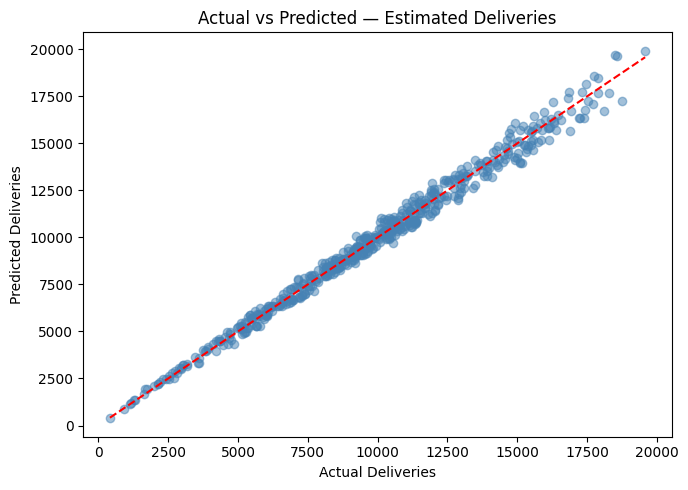

In [142]:

# Actual vs Predicted plot for Deliveries
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.5, color='steelblue')


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted — Estimated Deliveries')
plt.tight_layout()
plt.show()



>>> TIME SERIES FORECASTING
Forecasted Avg Price USD (next 12 months):
2026-01-01    82814.38
2026-02-01    83860.09
2026-03-01    82227.82
2026-04-01    84300.50
2026-05-01    84164.98
2026-06-01    85075.90
2026-07-01    84088.37
2026-08-01    84996.01
2026-09-01    87393.58
2026-10-01    86137.71
2026-11-01    85052.63
2026-12-01    84597.80
Freq: MS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


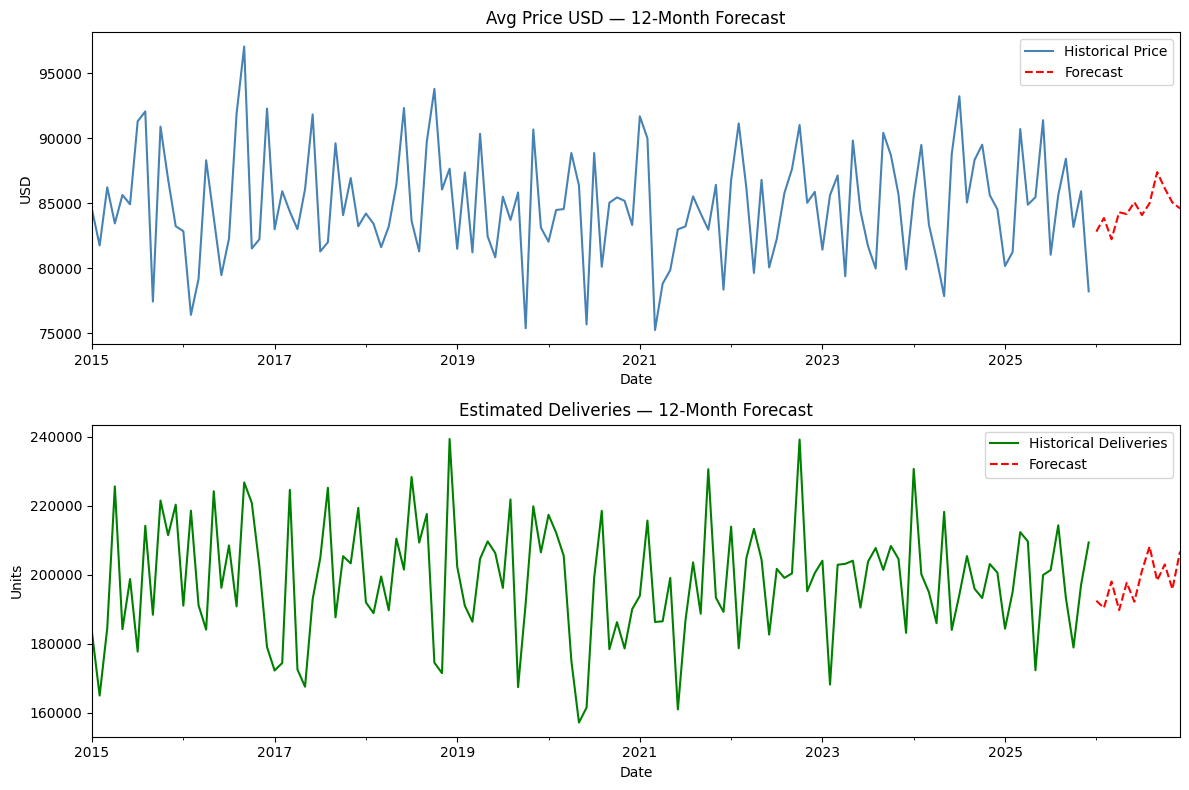

In [143]:
print("\n>>> TIME SERIES FORECASTING")


price_ts = df2.groupby('Date')['Avg_Price_USD'].mean().sort_index()

hw_price = ExponentialSmoothing(
    price_ts, trend='add', seasonal='add', seasonal_periods=12
).fit()

price_forecast = hw_price.forecast(12)

print("Forecasted Avg Price USD (next 12 months):")
print(price_forecast.round(2).to_string())

delivery_ts = df2.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

hw_delivery = ExponentialSmoothing(
    delivery_ts, trend='add', seasonal='add', seasonal_periods=12
).fit()

delivery_forecast = hw_delivery.forecast(12)

# Plot both forecasts
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

price_ts.plot(ax=axes[0], label='Historical Price', color='steelblue')
price_forecast.plot(ax=axes[0], label='Forecast', color='red', linestyle='--')
axes[0].set_title('Avg Price USD — 12-Month Forecast')
axes[0].set_ylabel('USD')
axes[0].legend()

delivery_ts.plot(ax=axes[1], label='Historical Deliveries', color='green')
delivery_forecast.plot(ax=axes[1], label='Forecast', color='red', linestyle='--')
axes[1].set_title('Estimated Deliveries — 12-Month Forecast')
axes[1].set_ylabel('Units')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("=" * 55)


>>> TIME SERIES FORECASTING (Estimated Deliveries)
Forecasted Total Deliveries (Next 12 Months):
2026-01-01    192503
2026-02-01    190435
2026-03-01    198071
2026-04-01    189794
2026-05-01    197737
2026-06-01    192220
2026-07-01    201206
2026-08-01    208206
2026-09-01    198375
2026-10-01    203017
2026-11-01    195870
2026-12-01    206739
Freq: MS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


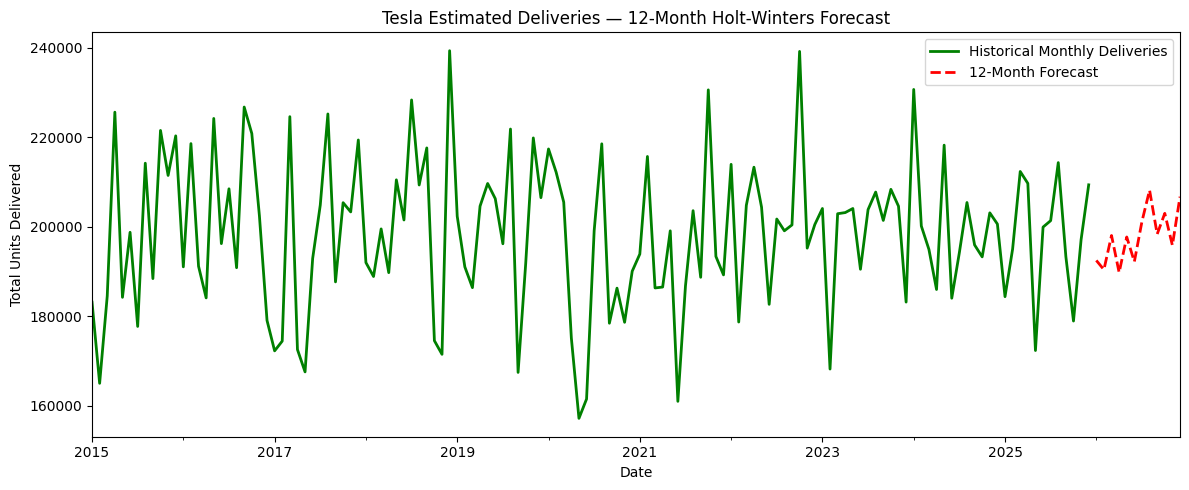


               PIPELINE COMPLETE


In [144]:
print("\n>>> TIME SERIES FORECASTING (Estimated Deliveries)")


delivery_ts = df2.groupby('Date')['Estimated_Deliveries'].sum().sort_index()


hw_delivery = ExponentialSmoothing(
    delivery_ts, 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
).fit()


delivery_forecast = hw_delivery.forecast(12)

print("Forecasted Total Deliveries (Next 12 Months):")
print(delivery_forecast.round(0).astype(int).to_string())


plt.figure(figsize=(12, 5))
delivery_ts.plot(label='Historical Monthly Deliveries', color='green', linewidth=2)
delivery_forecast.plot(label='12-Month Forecast', color='red', linestyle='--', linewidth=2)

plt.title('Tesla Estimated Deliveries — 12-Month Holt-Winters Forecast')
plt.xlabel('Date')
plt.ylabel('Total Units Delivered')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("               PIPELINE COMPLETE")

